In [31]:
from __future__ import annotations
from persistence.context import ModelContext
from domain.enums import HealthStates
from utils.logging import setup_root_logger
from utils.path_utils import get_project_root

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Notebook setup
# -----------------------------

logger = setup_root_logger()
root = get_project_root()
context = ModelContext.load()
path = root / "cache" / "owsa" / "parquet" / "all_results_combined.parquet"

df = pd.read_parquet(
    path=path,
    engine="auto",
    columns=[
        "scenario",
        "time_horizon",
        "regime",
        "extension",
        "sampling_method",
        "sampled_abr",
        "cycles",
        "observed_cycles",
        "person_years",
        "lost_person_years",
        "lost_person_year_life_expectancy",
        "total_factor",
        "total_qaly",
        "total_cost",
        "annual_cost",
        "pettersson_score",
        "absorbed_at",
        "is_absorbed",
        "bleeding_events",
        "spontaneous_bleeding_events",
        "joint_bleeding_events",
        "life_threatening_events",
        "annual_bleeding_rate",
        "spontaneous_bleeding_rate",
        "annual_joint_bleeding_rate",
        "annual_life_threatening_rate",
    ],
)
dropped_rows = [
    "early on_demand bayesian weight_low",
    "early prophylaxis bayesian weight_low",
    "lifetime on_demand bayesian weight_low",
    "lifetime prophylaxis bayesian weight_low",
    "early on_demand bayesian weight_high",
    "early prophylaxis bayesian weight_high",
    "lifetime on_demand bayesian weight_high",
    "lifetime prophylaxis bayesian weight_high",
]

df = df[~df["scenario"].isin(dropped_rows)]

regimes = df["regime"].unique()
scenarios = df["scenario"].unique()
states = [state.value for state in HealthStates]

logger.info("Data loaded successfully with %d rows", len(df))

[20:37:02] INFO     Data loaded successfully with 116000 rows


In [32]:
from notebook_tools.scenario_helpers import parse_scenario, pair_scenarios

pairs = pair_scenarios(df["scenario"].unique().tolist())

for control, intervention in pairs:
    control_df = df[df["scenario"] == control]
    intervention_df = df[df["scenario"] == intervention]

    control_cost = control_df["total_cost"].mean()
    intervention_cost = intervention_df["total_cost"].mean()

    control_qaly = control_df["total_qaly"].mean()
    intervention_qaly = intervention_df["total_qaly"].mean()

    incremental_cost = intervention_cost - control_cost
    incremental_qaly = intervention_qaly - control_qaly

    print(f"\n{intervention} vs {control}")

    print(f"Intervention ABR: {intervention_df['sampled_abr'].mean():,.0f}")
    print(f"Control ABR: {control_df['sampled_abr'].mean():,.0f}")

    print(f"Intervention cost: {intervention_cost:,.0f} IRR")
    print(f"Control cost:      {control_cost:,.0f} IRR")

    print(f"Intervention QALY: {intervention_qaly:.2f}")
    print(f"Control QALY:      {control_qaly:.2f}")

    print(f"Incremental cost:  {incremental_cost:,.0f} IRR")
    print(f"Incremental QALY:  {incremental_qaly:.2f}")

    if incremental_cost < 0 and incremental_qaly > 0:
        print("Result: Intervention is dominant")
    elif incremental_cost > 0 and incremental_qaly < 0:
        print("Result: Intervention is dominated")
    elif incremental_qaly == 0:
        print("Result: ICER undefined (ΔQALY = 0)")
    else:
        icer = incremental_cost / incremental_qaly
        print(f"ICER: {icer:,.0f} IRR/QALY")


early prophylaxis bayesian vs early on_demand bayesian
Intervention ABR: 4
Control ABR: 23
Intervention cost: 75,267,270,442 IRR
Control cost:      27,822,411,726 IRR
Intervention QALY: 8.54
Control QALY:      6.67
Incremental cost:  47,444,858,716 IRR
Incremental QALY:  1.87
ICER: 25,366,630,960 IRR/QALY

lifetime prophylaxis bayesian vs lifetime on_demand bayesian
Intervention ABR: 4
Control ABR: 23
Intervention cost: 1,309,384,644,618 IRR
Control cost:      259,860,115,438 IRR
Intervention QALY: 57.58
Control QALY:      25.77
Incremental cost:  1,049,524,529,180 IRR
Incremental QALY:  31.81
ICER: 32,992,807,974 IRR/QALY

early prophylaxis bayesian abr_low vs early on_demand bayesian abr_low
Intervention ABR: 2
Control ABR: 5
Intervention cost: 72,578,336,102 IRR
Control cost:      7,071,924,595 IRR
Intervention QALY: 8.76
Control QALY:      8.33
Incremental cost:  65,506,411,507 IRR
Incremental QALY:  0.43
ICER: 152,705,934,388 IRR/QALY

lifetime prophylaxis bayesian abr_low vs lif

In [33]:
from typing_extensions import Literal

from notebook_tools.scenario_helpers import (
    get_parameter_label,
    get_base_pair_key,
    split_tornado_extensions,
)
from notebook_tools.storage import store
from visualization.plots import OWSAPlotter

base_early_pair = pairs[:1]
base_lifetime_pair = pairs[1:2]

p_low, p_high = split_tornado_extensions(pairs[2:])

base_pairs = base_early_pair + base_lifetime_pair
base_results: dict[tuple[str, str], dict[str, float]] = {}
owsa_rows = []


def get_incremental(df: pd.DataFrame, pair: tuple[str, str]) -> dict[str, float]:
    """returns incremental cost and QALY for the intervention vs control in the pair"""

    control, intervention = pair
    control_df = df[df["scenario"] == control]
    intervention_df = df[df["scenario"] == intervention]

    return {
        "incremental_cost": intervention_df["total_cost"].mean()
        - control_df["total_cost"].mean(),
        "incremental_qaly": intervention_df["total_qaly"].mean()
        - control_df["total_qaly"].mean(),
    }


def calculate_icer(df: pd.Series) -> float:
    """Calculate ICER from incremental cost and QALY in the given DataFrame row."""
    incremental_cost = df["incremental_cost"]
    incremental_qaly = df["incremental_qaly"]

    if incremental_qaly == 0:
        return np.inf  # Avoid division by zero; interpret as infinitely costly per QALY
    else:
        return incremental_cost / incremental_qaly


base_results = {
    get_base_pair_key(control): get_incremental(
        df,
        (control, intervention),
    )
    for control, intervention in base_pairs
}


class ErrorMessages:
    MISSING_BASE_RESULT = "No base result found for scenario pair with control '{}'"
    UNEXPECTED_SUFFIX = "Unexpected suffix '{}' in scenario '{}'"


for control, intervention in p_low + p_high:

    time_horizon, regime, sampling_method, extension = parse_scenario(control)
    parameter = get_parameter_label(extension)
    suffix: Literal["low", "high"] = extension.rsplit("_", 1)[-1]  # type: ignore

    if suffix not in {"low", "high"}:
        raise ValueError(ErrorMessages.UNEXPECTED_SUFFIX.format(suffix, control))

    baseline_key = get_base_pair_key(control)
    base = base_results.get(baseline_key)

    if base is None:
        raise ValueError(ErrorMessages.MISSING_BASE_RESULT.format(control))

    summary = get_incremental(df, (control, intervention))

    # ICER calculations
    base_icer = calculate_icer(pd.Series(base))
    scenario_icer = calculate_icer(pd.Series(summary))
    icer_diff_from_base = scenario_icer - base_icer

    owsa_rows.append(
        {
            "time_horizon": time_horizon,
            "sampling_method": sampling_method,
            "parameter": parameter,
            "scenario_type": suffix,
            "incremental_cost": summary["incremental_cost"],
            "incremental_qaly": summary["incremental_qaly"],
            "icer": scenario_icer,
            "base_incremental_cost": base["incremental_cost"],
            "base_incremental_qaly": base["incremental_qaly"],
            "base_icer": base_icer,
            "icer_diff_from_base": icer_diff_from_base,
        }
    )

owsa_df = pd.DataFrame(owsa_rows)

# Pivot summary
owsa_icer_summary = owsa_df.pivot_table(
    index=["time_horizon", "sampling_method", "parameter"],
    columns="scenario_type",
    values="icer_diff_from_base",
    aggfunc="first",
).reset_index()


# Rename columns
owsa_icer_summary = owsa_icer_summary.rename(
    columns={
        "low": "low_icer_change",
        "high": "high_icer_change",
    }
)

# Sensitivity magnitude
owsa_icer_summary["magnitude"] = (
    owsa_icer_summary[["low_icer_change", "high_icer_change"]].abs().max(axis=1)
)
print("OWSA ICER summary table, outputs/owsa_icer_summary.csv:")
store(owsa_icer_summary, root / "outputs" / "owsa_icer_summary.csv", override=False)
print(owsa_icer_summary.sort_values("magnitude", ascending=False).head(20))

OWSA ICER summary table, outputs/owsa_icer_summary.csv:
File 'C:\Users\Jino\Desktop\University\NOKI\markov-chain-3-14\outputs\owsa_icer_summary.csv' already exists. Set override=True to overwrite.
scenario_type time_horizon sampling_method  \
0                    early        bayesian   
14                lifetime        bayesian   
25                lifetime        bayesian   
11                   early        bayesian   
4                    early        bayesian   
21                lifetime        bayesian   
9                    early        bayesian   
7                    early        bayesian   
23                lifetime        bayesian   
18                lifetime        bayesian   
1                    early        bayesian   
6                    early        bayesian   
5                    early        bayesian   
13                   early        bayesian   
10                   early        bayesian   
26                lifetime        bayesian   
27                lif


=== ICER Tornado Diagram (Dual Bars Style) ===


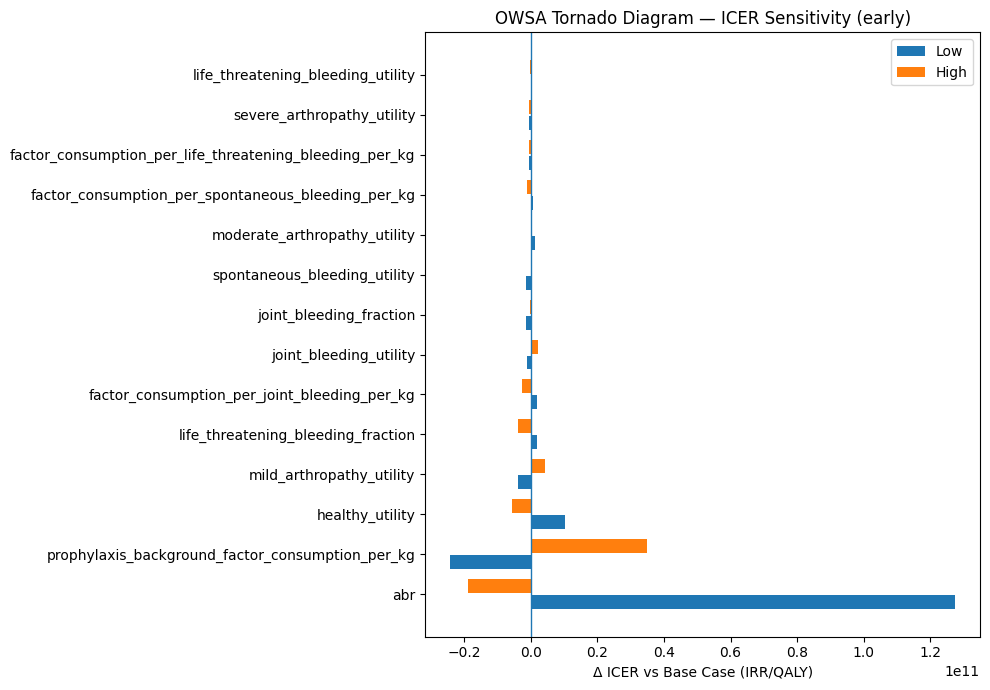

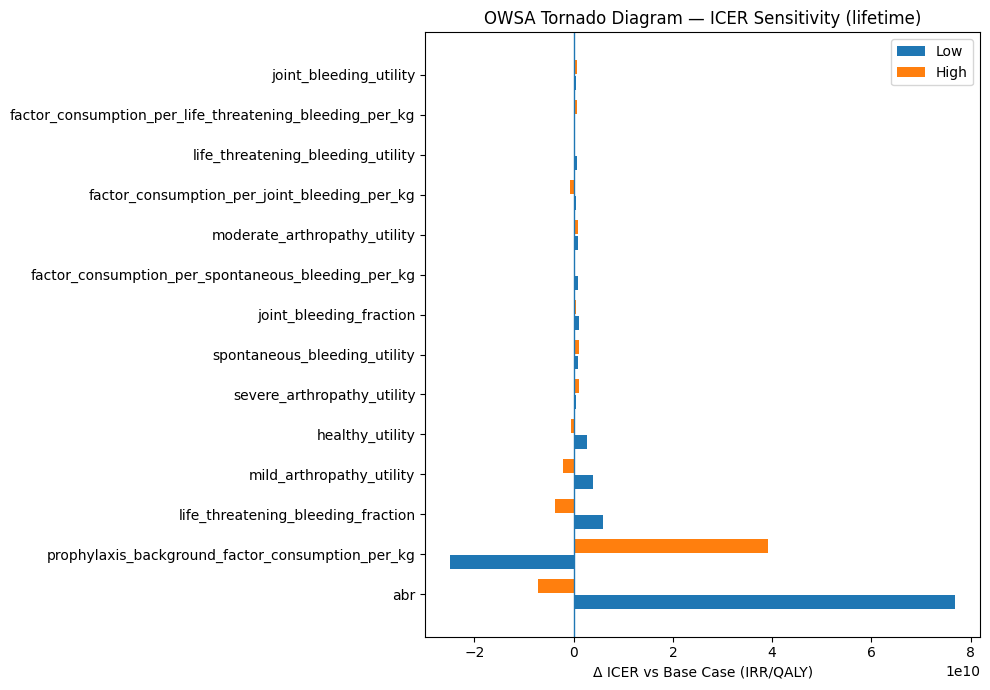

In [34]:
print("\n=== ICER Tornado Diagram (Dual Bars Style) ===")

OWSAPlotter.plot_owsa_icer_tornado(
    owsa_icer_summary,
    filter_horizon="early",
    style="dual_bars",
)

OWSAPlotter.plot_owsa_icer_tornado(
    owsa_icer_summary,
    filter_horizon="lifetime",
    style="dual_bars",
)


=== ICER Tornado Diagram (Errorbar Style - Compact) ===


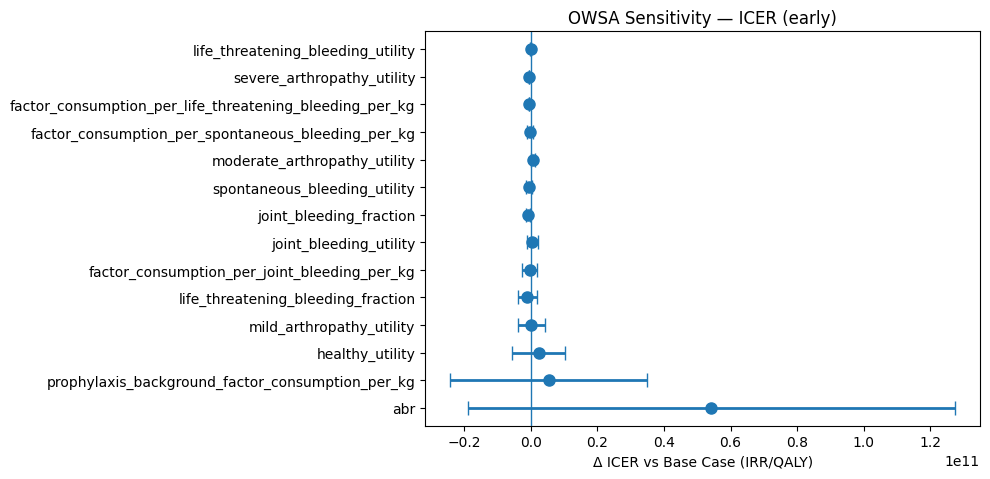

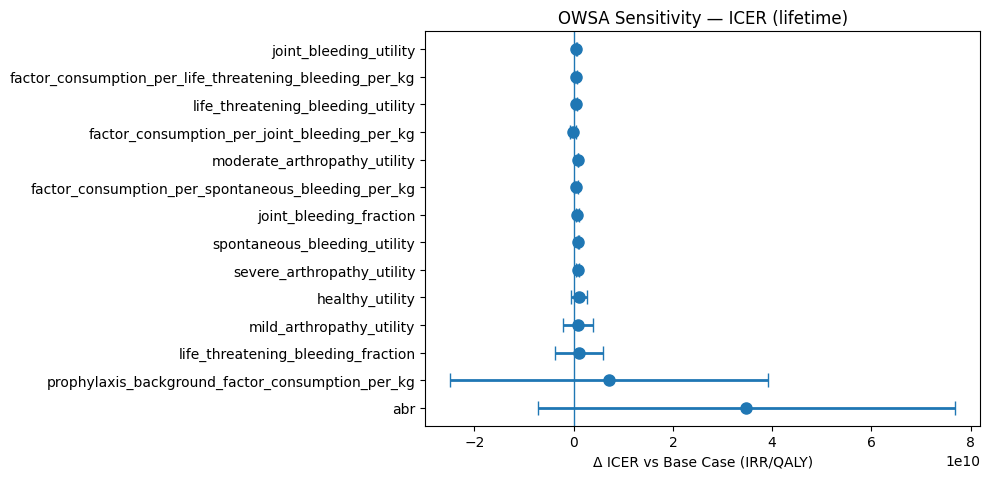

In [ ]:
# Plot using error bars (compact ICER style)
print("\n=== ICER Tornado Diagram (Errorbar Style - Compact) ===")
OWSAPlotter.plot_owsa_icer_tornado(
    owsa_icer_summary, filter_horizon="early", style="errorbar"
)
OWSAPlotter.plot_owsa_icer_tornado(
    owsa_icer_summary, filter_horizon="lifetime", style="errorbar"
)

In [36]:
# ============================================================
# ICER RESULTS INTERPRETATION & ONE-WAY SENSITIVITY ANALYSIS
# ============================================================

print("\n" + "=" * 90)
print("BASE-CASE COST-EFFECTIVENESS RESULTS")
print("=" * 90)

# -----------------------------
# Base-case ICER computation
# -----------------------------
baseline_table = []

for (time_horizon, sampling_method), results in base_results.items():

    delta_cost = results["incremental_cost"]
    delta_qaly = results["incremental_qaly"]

    base_icer = delta_cost / delta_qaly if delta_qaly != 0 else float("inf")

    baseline_table.append(
        {
            "Time Horizon": time_horizon,
            "Sampling Method": sampling_method,
            "Incremental Cost (IRR)": f"{delta_cost:,.0f}",
            "Incremental QALY": f"{delta_qaly:.4f}",
            "ICER (IRR/QALY)": (
                f"{base_icer:,.0f}" if base_icer != float("inf") else "Undefined"
            ),
        }
    )

baseline_df = pd.DataFrame(baseline_table)

print("\nBase-case results (Prophylaxis vs On-Demand):")
print(baseline_df.to_string(index=False))


# ============================================================
# ONE-WAY SENSITIVITY ANALYSIS (OWSA) — ICER TORNADO RANKING
# ============================================================

print("\n" + "=" * 90)
print("ONE-WAY SENSITIVITY ANALYSIS (ICER TORNADO RANKING)")
print("=" * 90)

for horizon in ["early", "lifetime"]:

    print(f"\n-----------------------------")
    print(f"TIME HORIZON: {horizon.upper()}")
    print(f"-----------------------------\n")

    subset = owsa_icer_summary[owsa_icer_summary["time_horizon"] == horizon].copy()

    if subset.empty:
        print("No OWSA results available for this time horizon.")
        continue

    # Sensitivity metric: maximum absolute deviation from base ICER
    subset["sensitivity"] = (
        subset[["low_icer_change", "high_icer_change"]].abs().max(axis=1)
    )

    subset = subset.sort_values("sensitivity", ascending=False)

    summary_table = []

    for _, row in subset.iterrows():

        summary_table.append(
            {
                "Parameter": row["parameter"],
                "ICER (Low Scenario)": f"{row['low_icer_change']:,.0f}",
                "ICER (High Scenario)": f"{row['high_icer_change']:,.0f}",
                "Absolute Range": f"{abs(row['high_icer_change'] - row['low_icer_change']):,.0f}",
                "Max Sensitivity": f"{row['sensitivity']:,.0f}",
            }
        )

    summary_df = pd.DataFrame(summary_table)

    print("Deterministic OWSA results ranked by ICER sensitivity:")
    print(summary_df.to_string(index=False))


# ============================================================
# ROBUSTNESS EVALUATION AGAINST COST-EFFECTIVENESS THRESHOLD
# ============================================================

print("\n" + "=" * 90)
print("COST-EFFECTIVENESS ROBUSTNESS ANALYSIS")
print("=" * 90)

gdp_per_capita = context.economic_policy.gdp_per_capita.IRR
disease_wtp_ratio = context.economic_policy.wtp_multiplier.rare
WTP = gdp_per_capita * disease_wtp_ratio
ce_threshold = WTP  # IRR per QALY

print(f"\nWillingness-to-pay threshold: {ce_threshold:,.0f} IRR/QALY")

for horizon in ["early", "lifetime"]:

    key = (horizon, "bayesian")

    if key not in base_results:
        continue

    result = base_results[key]

    base_cost = result["incremental_cost"]
    base_qaly = result["incremental_qaly"]

    base_icer = base_cost / base_qaly if base_qaly != 0 else float("inf")

    print(f"\n-----------------------------")
    print(f"{horizon.upper()} HORIZON")
    print(f"-----------------------------")

    print(f"Base-case ICER: {base_icer:,.0f} IRR/QALY")

    base_ce = base_icer < ce_threshold
    print(
        f"Cost-effectiveness status: {'Cost-effective' if base_ce else 'Not cost-effective'}"
    )

    owsa_subset = owsa_icer_summary[owsa_icer_summary["time_horizon"] == horizon]

    if not owsa_subset.empty:

        max_dev = owsa_subset[["low_icer_change", "high_icer_change"]].abs().max().max()

        worst_case = base_icer + max_dev
        best_case = base_icer - max_dev

        print("\nOWSA impact on ICER:")
        print(f"Maximum parameter-driven deviation: ±{max_dev:,.0f} IRR/QALY")

        print(
            f"ICER range (best–worst case): {best_case:,.0f} – {worst_case:,.0f} IRR/QALY"
        )

        worst_ce = worst_case < ce_threshold
        best_ce = best_case < ce_threshold

        if base_ce == worst_ce == best_ce:
            print("Conclusion: Robust cost-effectiveness across parameter uncertainty.")
        else:
            print(
                "Conclusion: Cost-effectiveness is sensitive to parameter uncertainty."
            )

            if base_ce and not worst_ce:
                print(
                    "Risk: May become not cost-effective under pessimistic assumptions."
                )
            elif not base_ce and best_ce:
                print(
                    "Opportunity: May become cost-effective under optimistic assumptions."
                )


BASE-CASE COST-EFFECTIVENESS RESULTS

Base-case results (Prophylaxis vs On-Demand):
Time Horizon Sampling Method Incremental Cost (IRR) Incremental QALY ICER (IRR/QALY)
       early        bayesian         47,444,858,716           1.8704  25,366,630,960
    lifetime        bayesian      1,049,524,529,180          31.8107  32,992,807,974

ONE-WAY SENSITIVITY ANALYSIS (ICER TORNADO RANKING)

-----------------------------
TIME HORIZON: EARLY
-----------------------------

Deterministic OWSA results ranked by ICER sensitivity:
                                              Parameter ICER (Low Scenario) ICER (High Scenario)  Absolute Range Max Sensitivity
                                                    abr     127,339,303,427      -18,903,465,812 146,242,769,239 127,339,303,427
       prophylaxis_background_factor_consumption_per_kg     -24,088,231,705       34,837,064,111  58,925,295,816  34,837,064,111
                                        healthy_utility      10,348,732,606       -